In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("./pred_log.csv")

In [5]:
df["label"] = df['src_path'].str.split("/").map(lambda x: x[5])

In [6]:
(df["pred_label"] == df["label"]).mean()

np.float64(0.9464720194647201)

/tmp/ipykernel_3671/1202630289.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[["pred_label", "label"]].groupby("label").apply(lambda x: (x["pred_label"] == x["label"]).mean()).plot.barh()


<Axes: ylabel='label'>

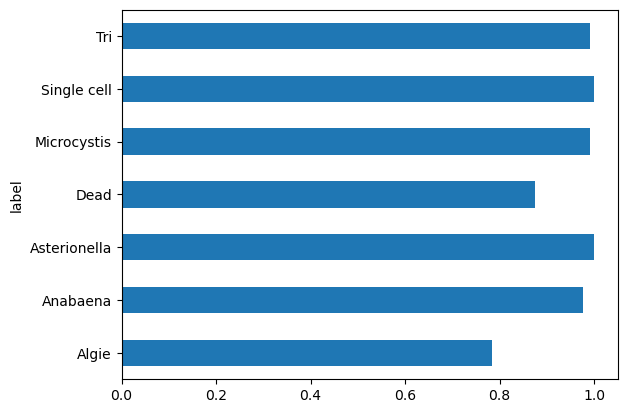

In [7]:
df[["pred_label", "label"]].groupby("label").apply(lambda x: (x["pred_label"] == x["label"]).mean()).plot.barh()

pred_label,Algie,Anabaena,Asterionella,Dead,Microcystis,Single cell,Tri
label,,,,,,,
Algie,175,1,1,7,23,16,0
Anabaena,1,241,1,2,0,2,0
Asterionella,0,0,70,0,0,0,0
Dead,1,1,0,49,1,4,0
Microcystis,3,0,0,0,349,0,0
Single cell,0,0,0,0,0,69,0
Tri,1,0,0,0,0,1,214


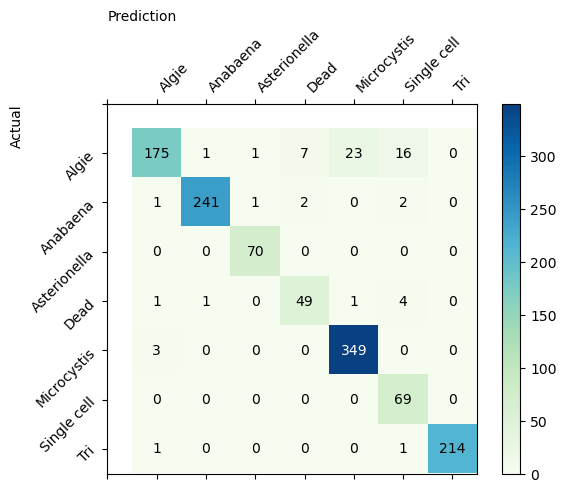

In [8]:
confusion = pd.crosstab(df["label"], df["pred_label"])

fig = plt.figure()
ax = fig.add_subplot(111)

display(confusion)

cax = ax.matshow(confusion, cmap="GnBu")
ax.set_xticks(ticks=range(-1, confusion.index.size), labels=[""] + list(confusion.columns), rotation=45, ha="left")
ax.set_yticks(ticks=range(-1, confusion.index.size), labels=[""] + list(confusion.index), rotation=45, ha="right")
ax.set_xlabel("Prediction", loc="left")
ax.set_ylabel("Actual", loc="top")
ax.xaxis.set_label_position('top') 

for i, ind in enumerate(confusion.index):
    for j, col in enumerate(confusion.columns):
        val = confusion[col][ind]
        text = ax.text(j, i, val,
                       ha="center", va="center", color="k" if val < 250 else "w")

fig.colorbar(cax)

,Precision,Recall,$\mathregular{F_1}$ score
label,,,
Algie,0.966851,0.784753,0.866337
Anabaena,0.991770,0.975709,0.983673
Asterionella,0.972222,1.000000,0.985915
Dead,0.844828,0.875000,0.859649
Microcystis,0.935657,0.991477,0.962759
Single cell,0.750000,1.000000,0.857143
Tri,1.000000,0.990741,0.995349


<Figure size 640x480 with 0 Axes>

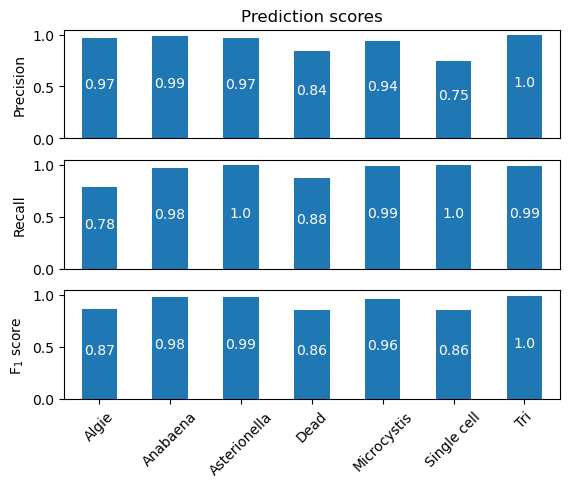

In [17]:
true_positive = pd.Series(np.diag(confusion), index=confusion.index)
precision = true_positive / confusion.sum(axis="rows")
recall = true_positive / confusion.sum(axis="columns")

f1_score = (2 * precision * recall) / (precision + recall)

fig = plt.figure()

chart_def = {
    "Precision": precision,
    "Recall": recall,
    "$\\mathregular{F_1}$ score": f1_score
}

display(pd.DataFrame(chart_def))

for (i, (ax, (label, values))) in enumerate(zip(plt.subplots(len(chart_def), 1)[1], chart_def.items())):
    last_plot_values = dict(rot=45) if i+1 == len(chart_def) else dict(xticks=[])
    if i == 0:
        last_plot_values["title"] = "Prediction scores"

    values.plot(kind="bar", ylabel=label, xlabel="", ax=ax, **last_plot_values)

    for p in ax.patches:
        ax.annotate(f"{p.get_height():.2}", (p.get_x() + p.get_width() / 2, p.get_height() / 2), ha="center", color="w")
